# Sweep aggregation

Loads every per-cell summary produced by `run_sweep.py` (default `dev/sweep/`) and visualises how each analysis metric varies across the 3^4 = 81 parameter combinations.

**Layout of the small-multiples figures.** Each figure = one metric. Outer grid rows = `wall_density` band, outer cols = `max_assignment_gap`. Within each panel, x = `min_switching_cost`, y = `geometric_pref_threshold`, colour = the metric's value on that cell. Every panel of a figure shares the same colour scale so panels are directly comparable.

In [1]:
from __future__ import annotations

import json
from pathlib import Path
from typing import List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SWEEP_ROOT = Path("sweep")  # relative to this notebook (dev/sweep)
INDEX_PATH = SWEEP_ROOT / "index.json"

## Load every cell into one wide DataFrame

One row per cell; columns = sweep params + every scalar reported by `analyze_grids_lite`.

In [2]:
index = json.load(open(INDEX_PATH))
cells = index["cells"]
print(f"index counts: {index['counts']}  wall={index['wall_seconds']:.0f}s")

META_FIELDS = [
    "realized_wall_density",
    "num_junctions",
    "num_dead_ends",
    "num_shortest_paths_ego_red",
    "num_shortest_paths_ego_blue",
    "num_shortest_paths_partner_red",
    "num_shortest_paths_partner_blue",
    "shortest_path_overlap_assignment_1",
    "shortest_path_overlap_assignment_2",
    "assignment_cost_difference",
    "switching_cost_mean",
    "switching_cost_min",
]

BASELINE_NAMES = ["nearest", "wait_react", "random"]


def _load_summary(summ_dir: Path) -> Optional[dict]:
    files = list(summ_dir.glob("*_summary.json"))
    if not files:
        return None
    return json.load(open(files[0]))


def _wd_label(wd: List[float]) -> str:
    return f"{wd[0]:.2f}-{wd[1]:.2f}"


rows: List[dict] = []
pair_keys: List[str] = []
for cid, cell in cells.items():
    if cell["status"] not in ("ok", "skipped_cached"):
        continue
    summ = _load_summary(SWEEP_ROOT / cell["summ_dir"])
    if summ is None:
        continue
    p = cell["params"]
    row = {
        "cell_id": cid,
        "wd_label": _wd_label(p["wall_density"]),
        "wd_lo": p["wall_density"][0], "wd_hi": p["wall_density"][1],
        "gap": int(p["max_assignment_gap"]),
        "sw":  float(p["min_switching_cost"]),
        "geo": int(p["geometric_pref_threshold"]),
        "n":   int(summ.get("n", -1)),
    }
    # metadata (median only for the plots)
    for f in META_FIELDS:
        stat = summ["metadata_distributions"].get(f) or {}
        row[f"meta__{f}"] = stat.get("median")
    # pairwise spearman (rho only)
    for pair in summ["pairwise_spearman"]:
        key = f"corr__{pair['x']}__{pair['y']}"
        row[key] = pair.get("rho")
        if key not in pair_keys:
            pair_keys.append(key)
    # baselines
    bl = (summ.get("baselines") or {}).get("baselines", {})
    for name in BASELINE_NAMES:
        b = bl.get(name, {})
        row[f"base__{name}__mean_success"] = b.get("mean_success")
        row[f"base__{name}__mean_cost"]    = b.get("mean_cost")
    rows.append(row)

df = pd.DataFrame(rows)
print(f"loaded {len(df)} cells")
df.head(2)

index counts: {'total': 81, 'ok': 81, 'cached': 0, 'failed': 0}  wall=949s
loaded 81 cells


,cell_id,wd_label,wd_lo,wd_hi,gap,sw,geo,n,meta__realized_wall_density,meta__num_junctions,...,corr__realized_wall_density__assignment_cost_difference,corr__realized_wall_density__num_junctions,corr__switching_cost_min__switching_cost_mean,corr__shortest_path_overlap_assignment_1__assignment_cost_difference,base__nearest__mean_success,base__nearest__mean_cost,base__wait_react__mean_success,base__wait_react__mean_cost,base__random__mean_success,base__random__mean_cost
0,wd0.15-0.35_gap3_sw1_geo1,0.15-0.35,0.15,0.35,3,1.0,1,100,0.204082,23.0,...,0.008729,-0.919386,0.707761,-0.098777,0.1207,6.000000,0.9072,8.563031,0.4930,6.823714
1,wd0.15-0.35_gap3_sw1_geo2,0.15-0.35,0.15,0.35,3,1.0,2,100,0.204082,24.0,...,0.083504,-0.942873,0.649825,0.152401,0.1242,5.714286,0.9410,8.513107,0.4984,6.949666


## Plotting helper

In [3]:
def plot_metric_grid(df: pd.DataFrame, metric: str, title: str,
                     cmap: str = "viridis",
                     vlim: Optional[Tuple[float, float]] = None,
                     fmt: str = "{:.2f}"):
    """Small-multiples heatmap of `metric` over the full 3^4 sweep grid.

    Outer grid: rows = wall_density band, cols = max_assignment_gap.
    Inner panel: y = geometric_pref_threshold (top = highest), x = min_switching_cost.
    """
    wds  = sorted(df["wd_label"].unique())
    gaps = sorted(df["gap"].unique())
    sws  = sorted(df["sw"].unique())
    geos = sorted(df["geo"].unique(), reverse=True)  # highest at top of panel

    vals = df[metric].to_numpy(dtype=float)
    if vlim is None:
        finite = vals[np.isfinite(vals)]
        vmin, vmax = (float(finite.min()), float(finite.max())) if finite.size else (0.0, 1.0)
        if vmin == vmax:
            vmin, vmax = vmin - 0.5, vmax + 0.5
    else:
        vmin, vmax = vlim

    fig, axes = plt.subplots(len(wds), len(gaps),
                              figsize=(2.8 * len(gaps) + 1.0, 2.6 * len(wds) + 0.6),
                              sharex=True, sharey=True, squeeze=False)
    im = None
    for i, wd in enumerate(wds):
        for j, gap in enumerate(gaps):
            ax = axes[i, j]
            sub = df[(df["wd_label"] == wd) & (df["gap"] == gap)]
            grid = np.full((len(geos), len(sws)), np.nan)
            for _, r in sub.iterrows():
                gi = geos.index(int(r["geo"]))
                si = sws.index(float(r["sw"]))
                grid[gi, si] = r[metric] if r[metric] is not None else np.nan
            im = ax.imshow(grid, vmin=vmin, vmax=vmax, cmap=cmap, aspect="auto")
            for gi in range(len(geos)):
                for si in range(len(sws)):
                    v = grid[gi, si]
                    if np.isnan(v):
                        ax.text(si, gi, "—", ha="center", va="center", fontsize=8, color="gray")
                        continue
                    norm = (v - vmin) / (vmax - vmin + 1e-12)
                    ax.text(si, gi, fmt.format(v), ha="center", va="center",
                            fontsize=7,
                            color="white" if norm > 0.55 else "black")
            ax.set_xticks(range(len(sws)))
            ax.set_xticklabels([str(s) for s in sws], fontsize=8)
            ax.set_yticks(range(len(geos)))
            ax.set_yticklabels([str(g) for g in geos], fontsize=8)
            if i == 0:
                ax.set_title(f"gap={gap}", fontsize=9)
            if j == 0:
                ax.set_ylabel(f"wd=[{wd}]\n\ngeo_pref", fontsize=8)
            if i == len(wds) - 1:
                ax.set_xlabel("min_switching_cost", fontsize=8)

    fig.suptitle(title, fontsize=12)
    fig.tight_layout(rect=(0, 0, 0.94, 0.98))
    if im is not None:
        cax = fig.add_axes([0.95, 0.15, 0.015, 0.7])
        fig.colorbar(im, cax=cax)
    return fig

## 1. Metadata medians across the sweep

One figure per metadata field. Each cell of a figure is the **median value** of that field over the 100 layouts generated with that parameter combination.

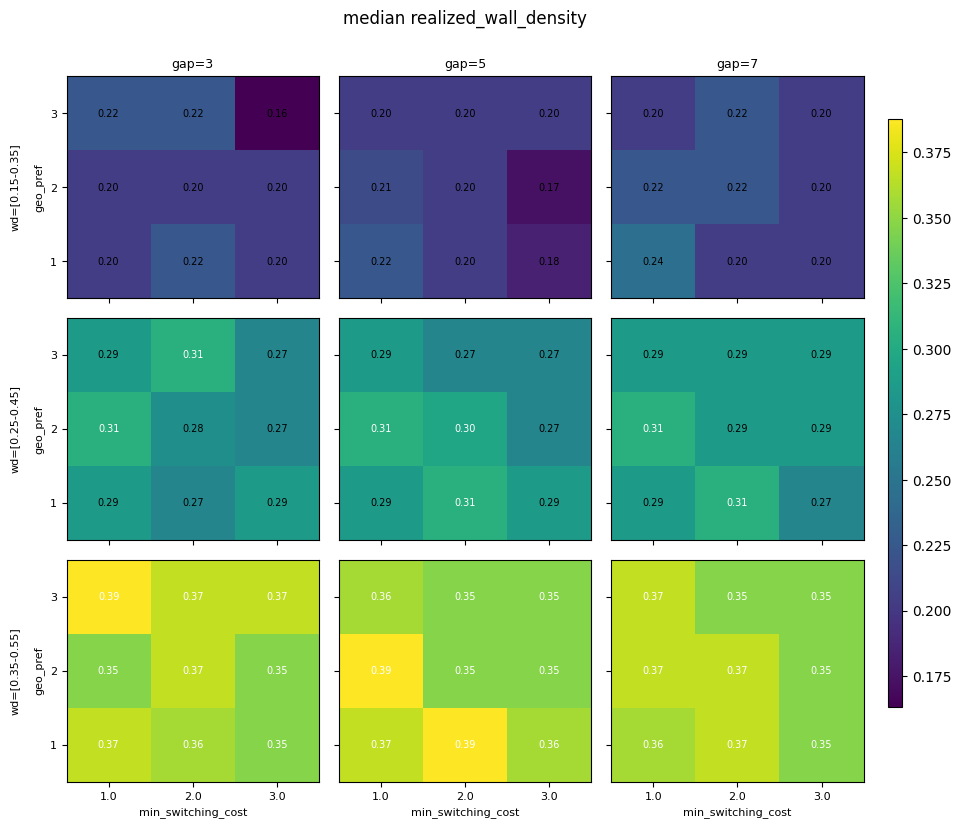

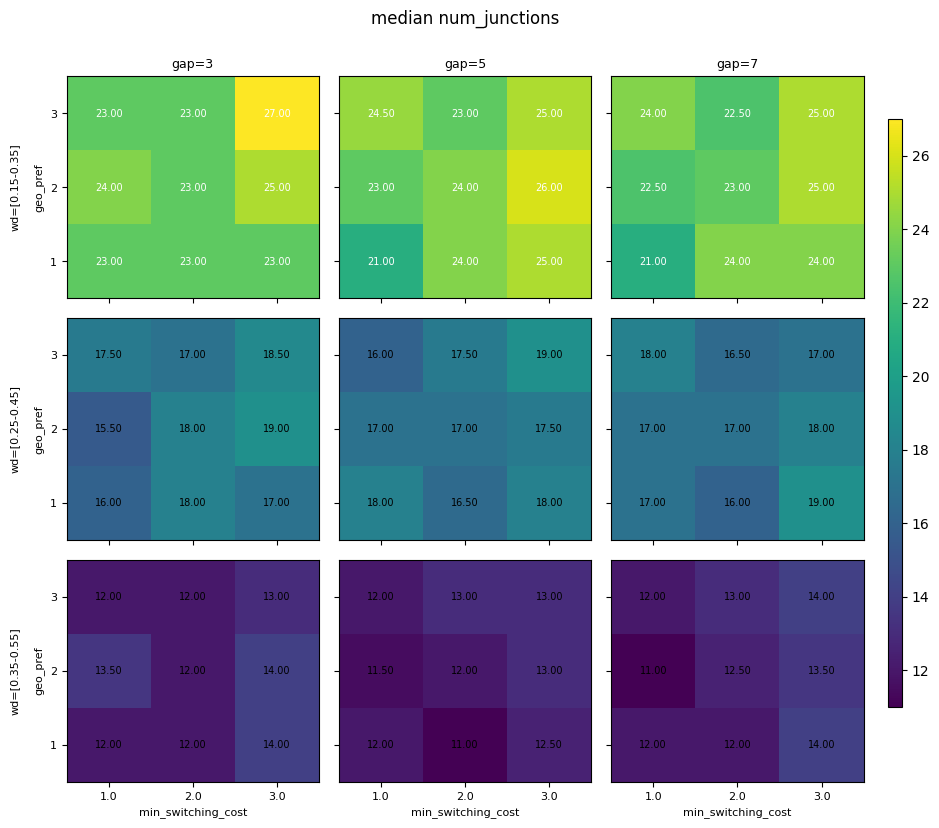

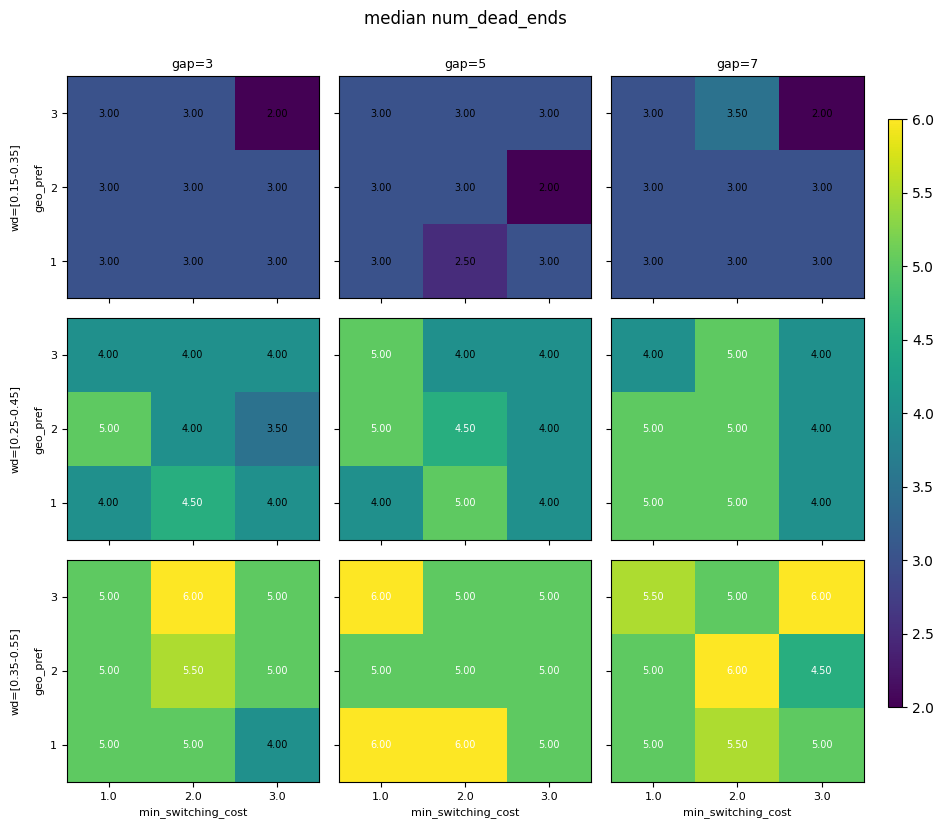

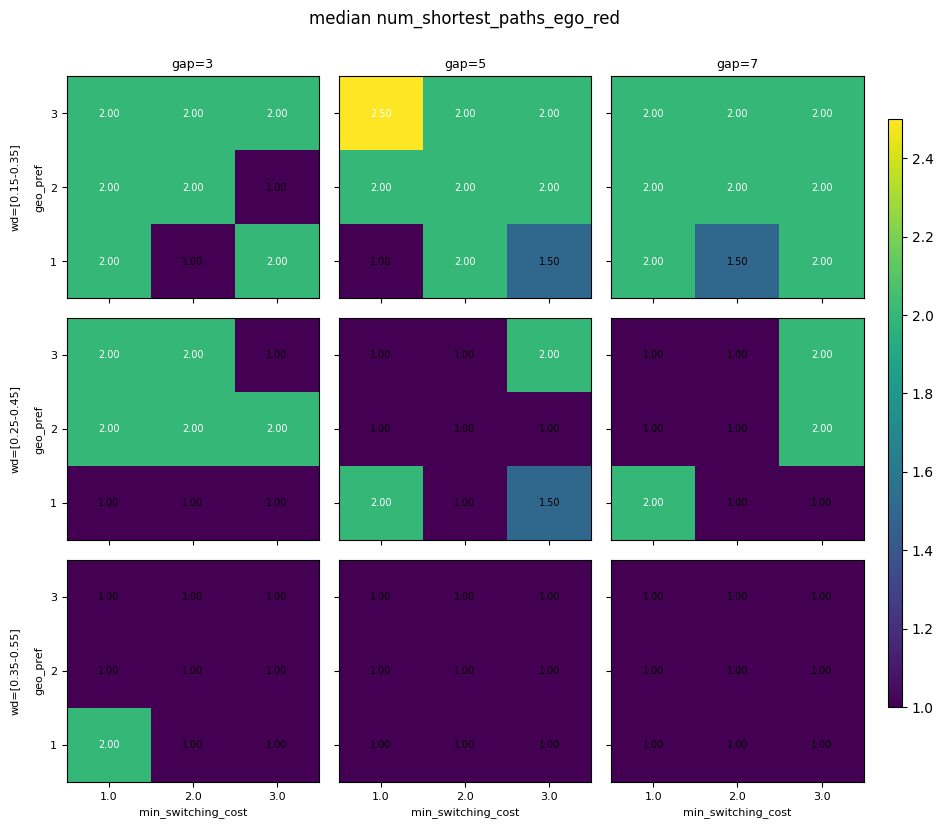

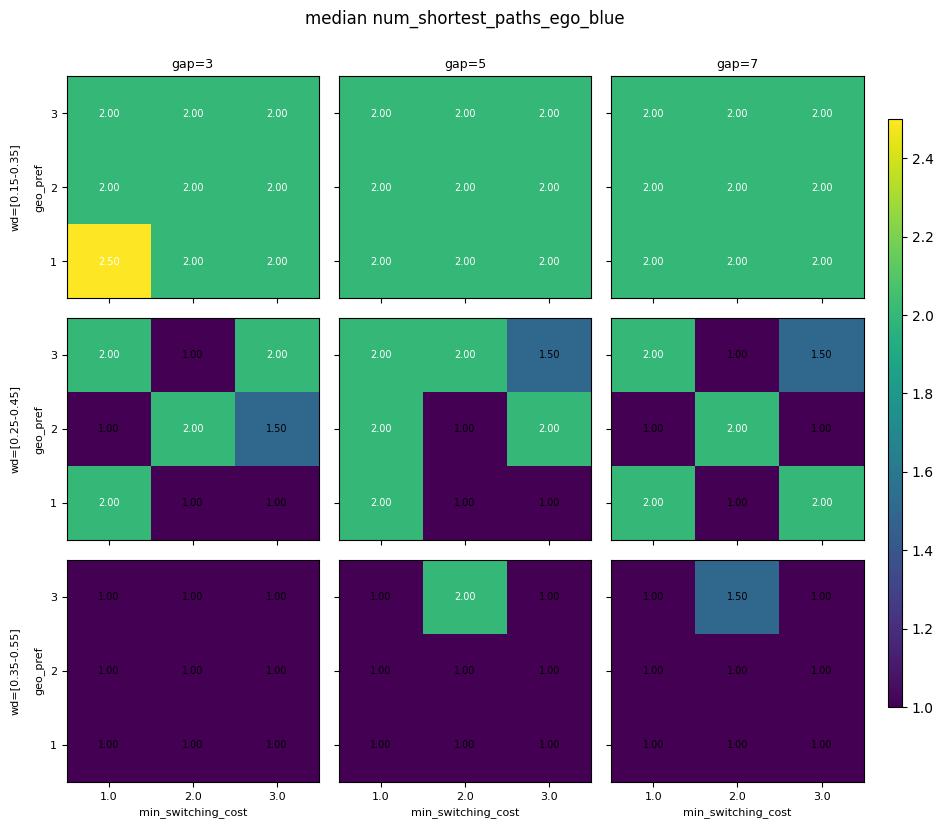

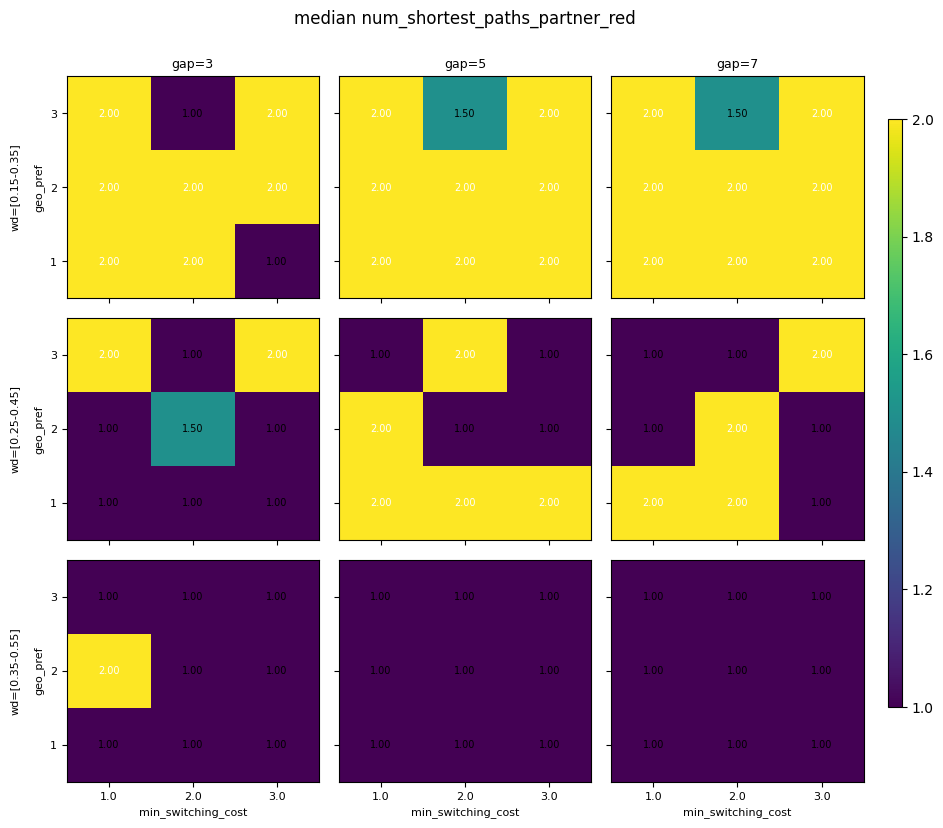

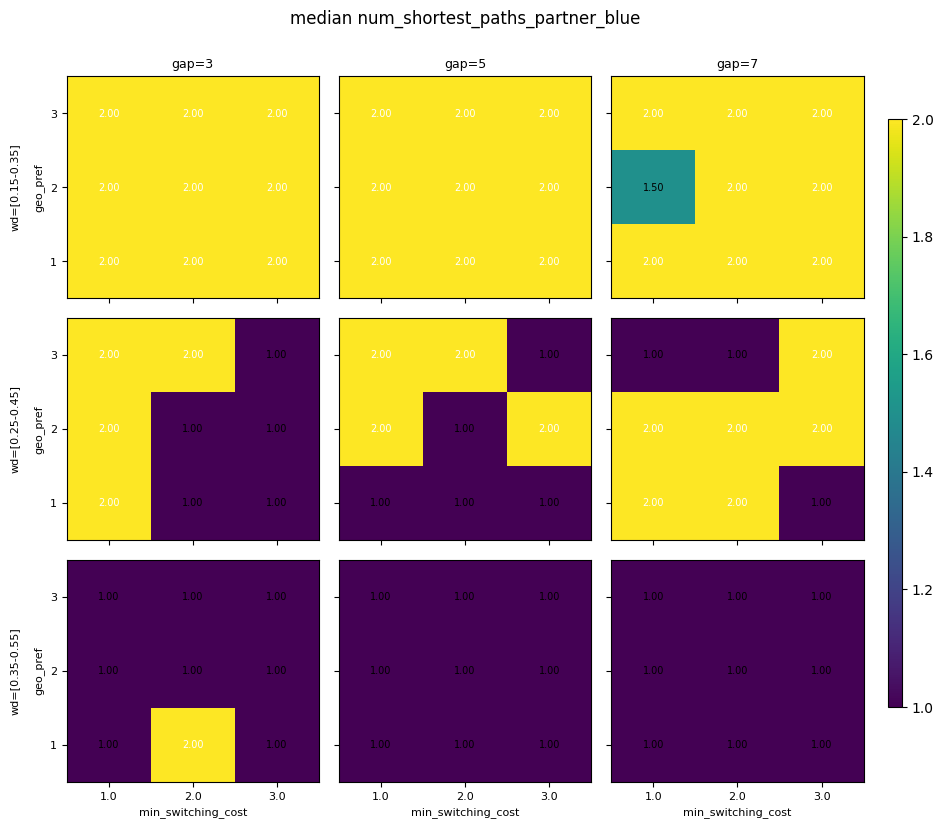

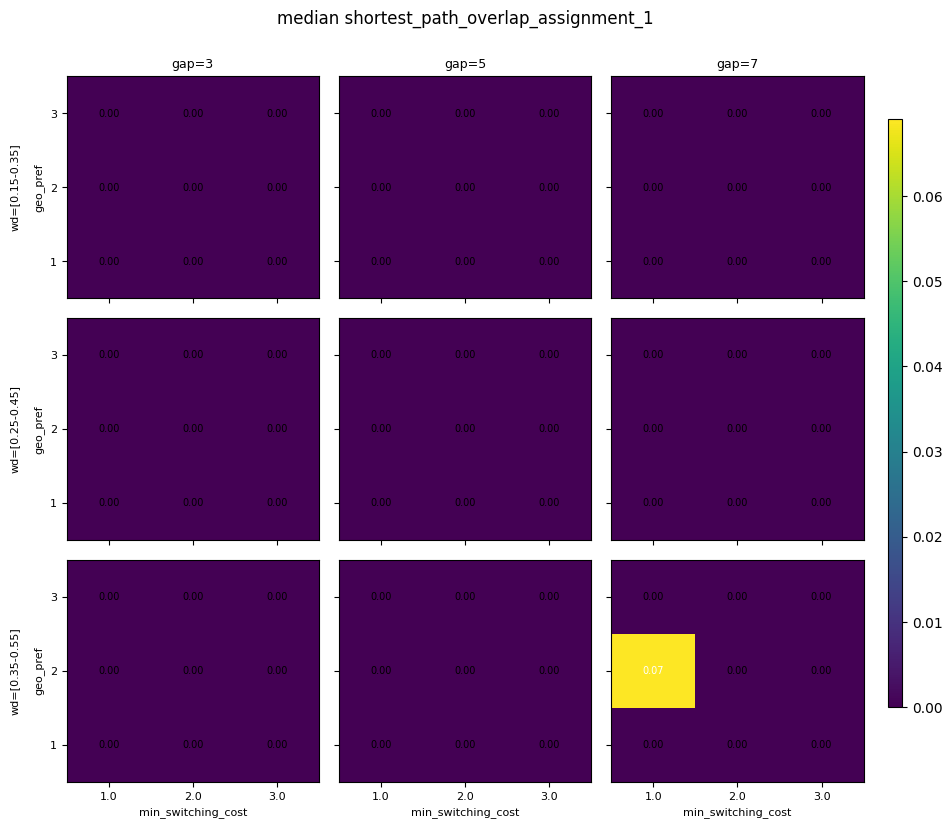

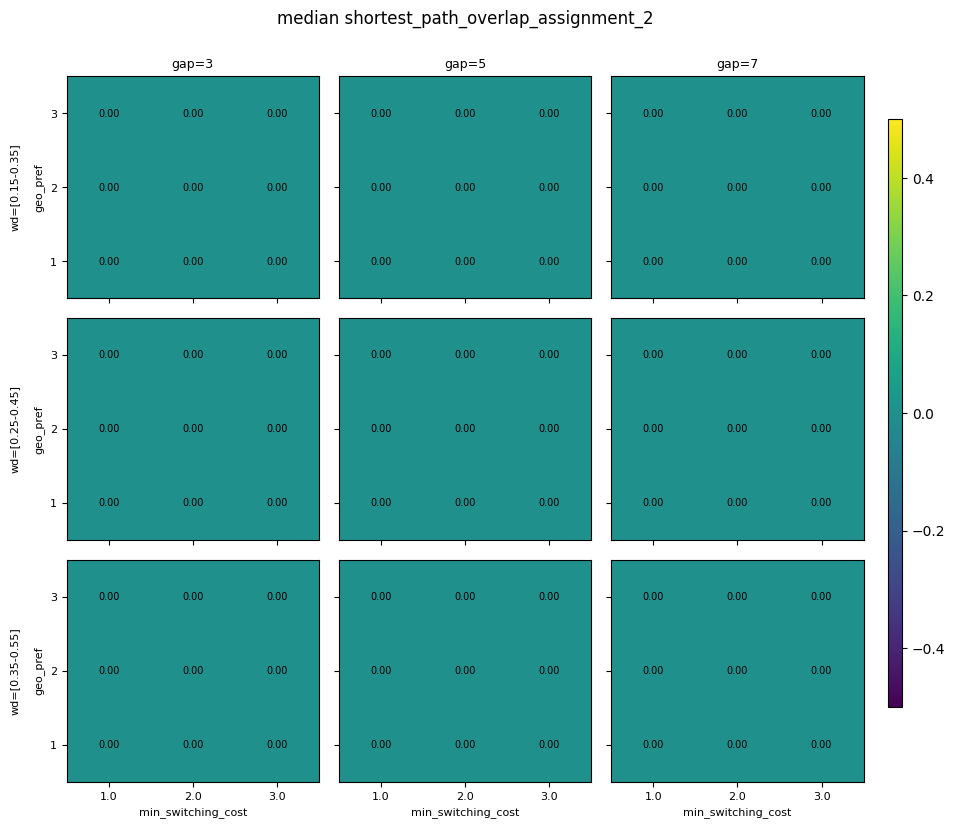

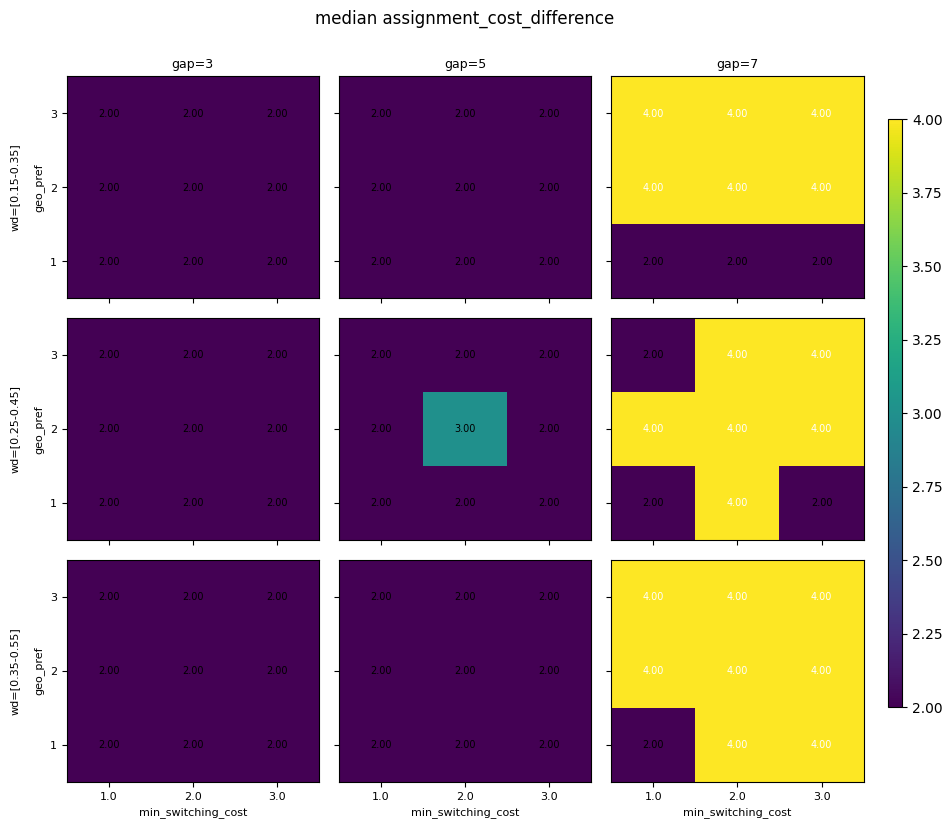

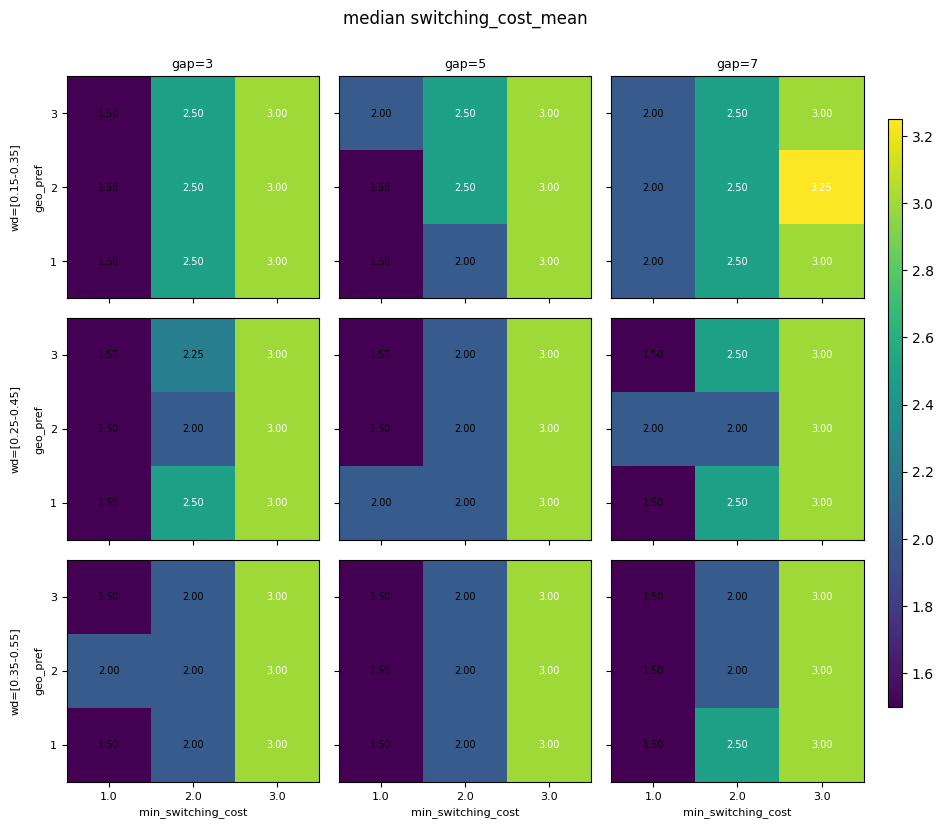

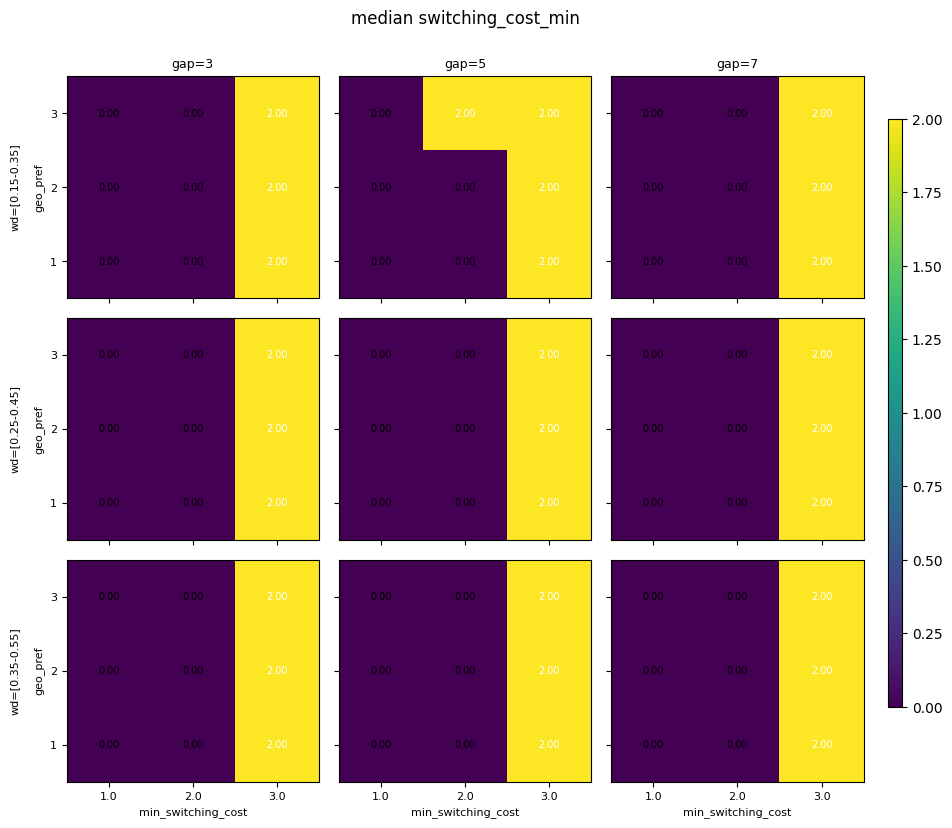

In [4]:
for f in META_FIELDS:
    col = f"meta__{f}"
    plot_metric_grid(df, col, f"median {f}", cmap="viridis")
    plt.show()

## 2. Pairwise Spearman correlations across the sweep

One figure per descriptor pair. Colour = Spearman ρ inside that cell's 100-layout sample; diverging colormap centered at 0, fixed to [-1, +1].

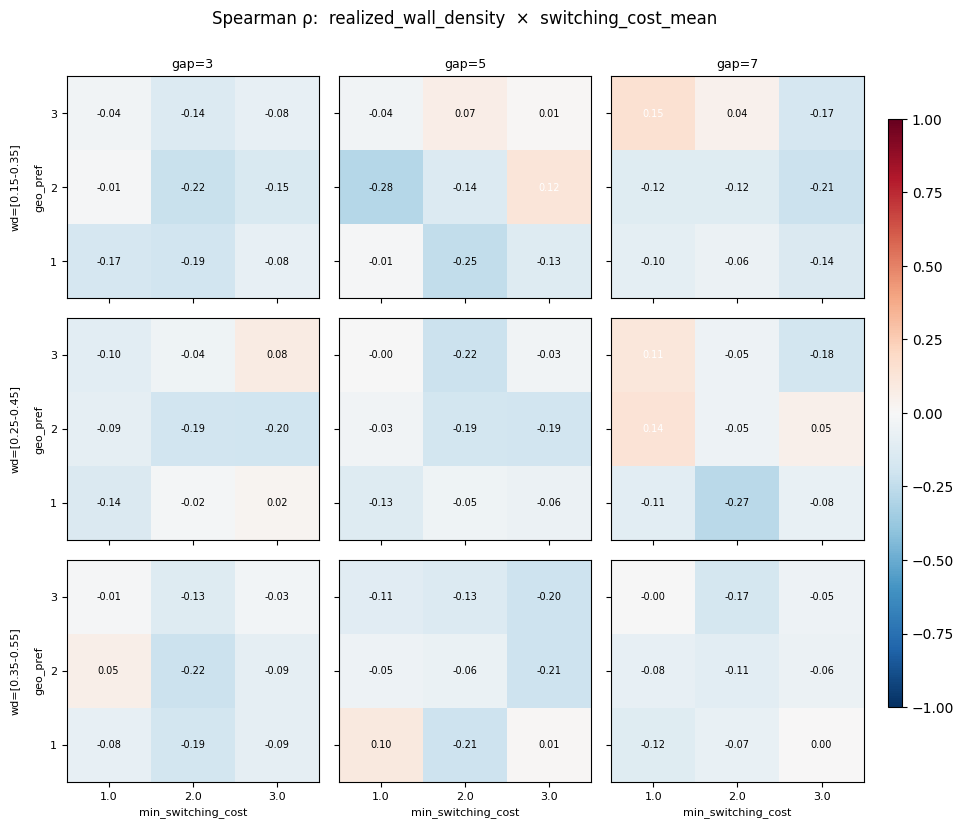

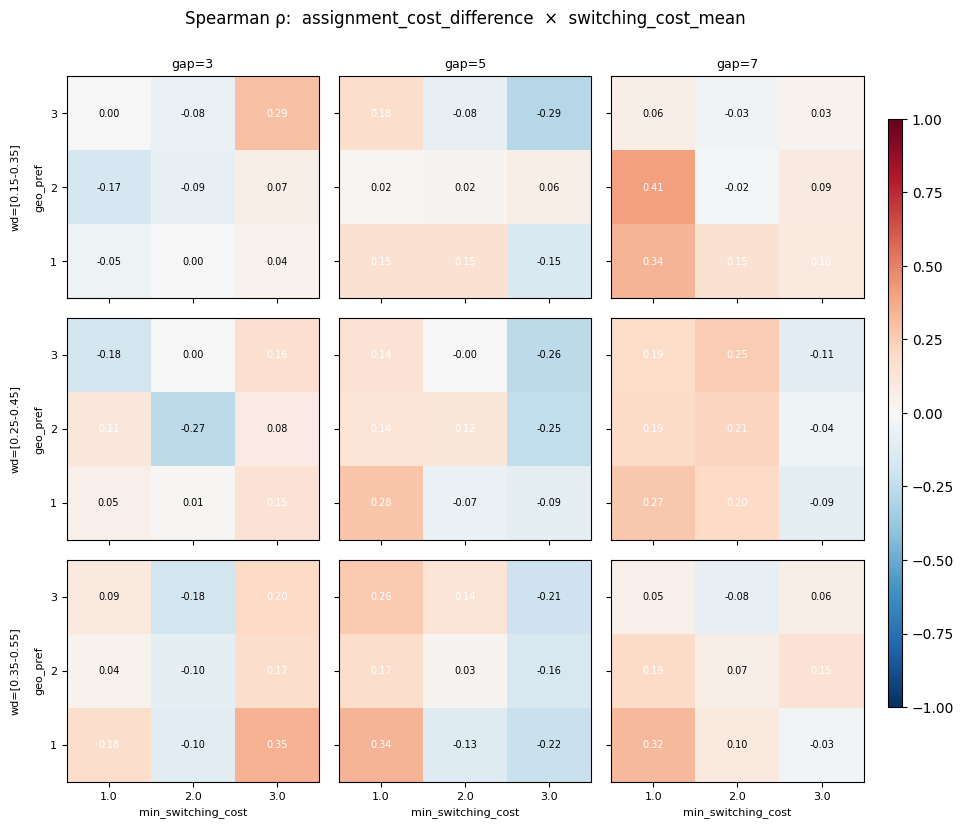

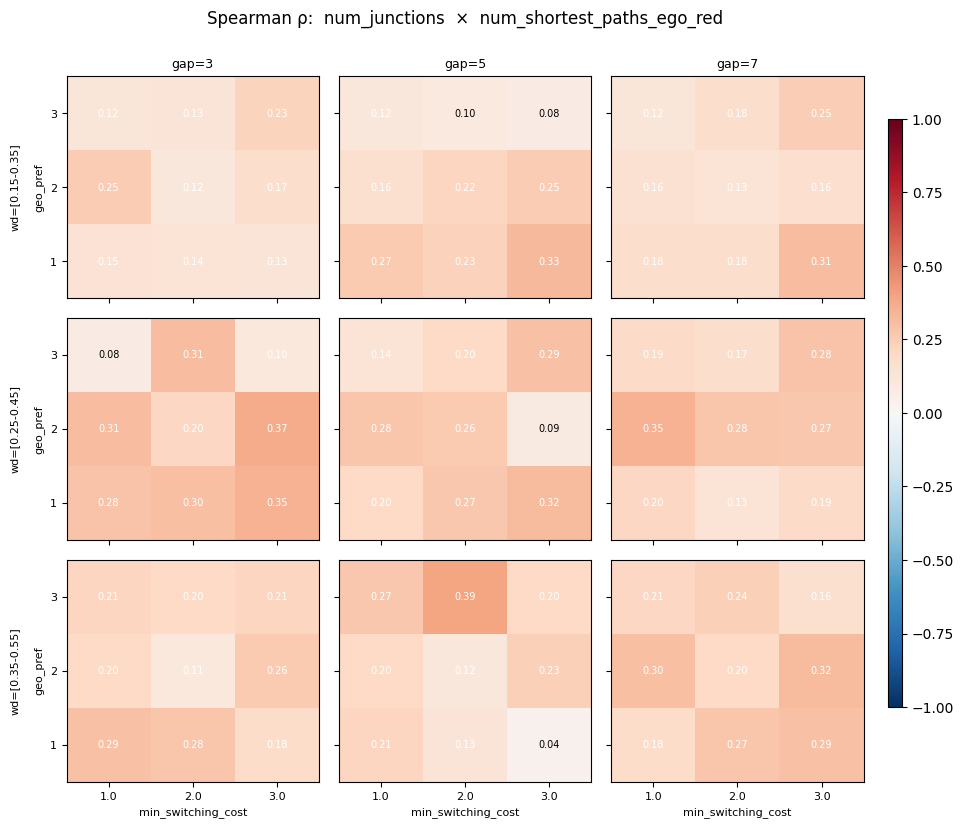

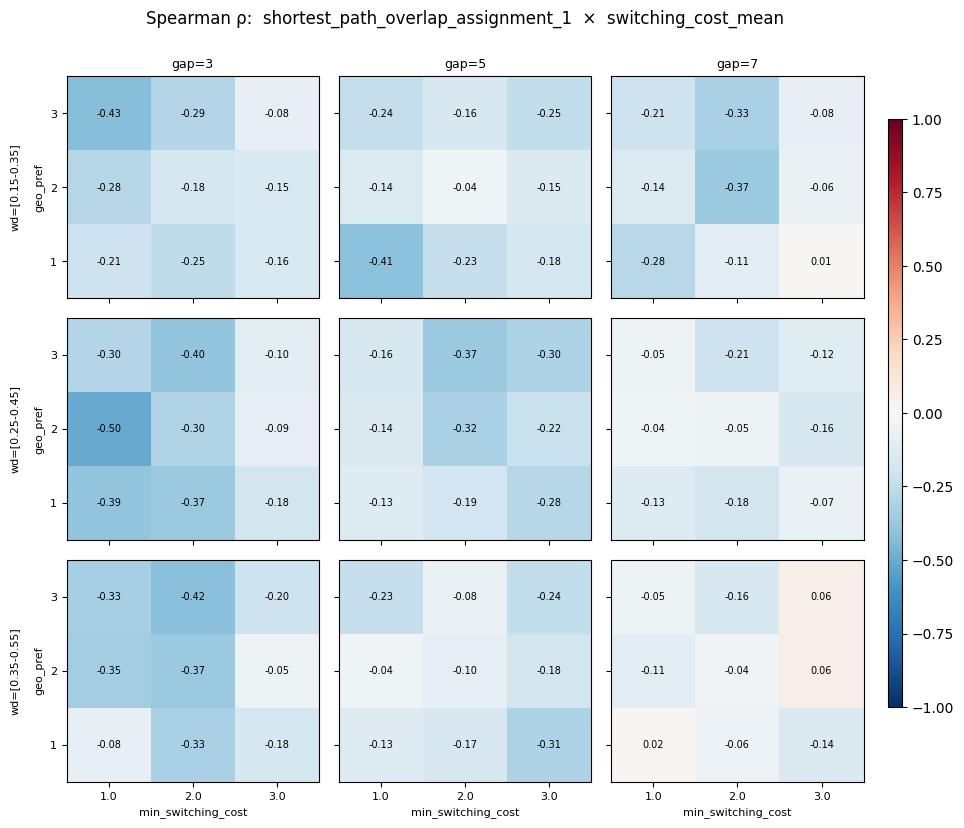

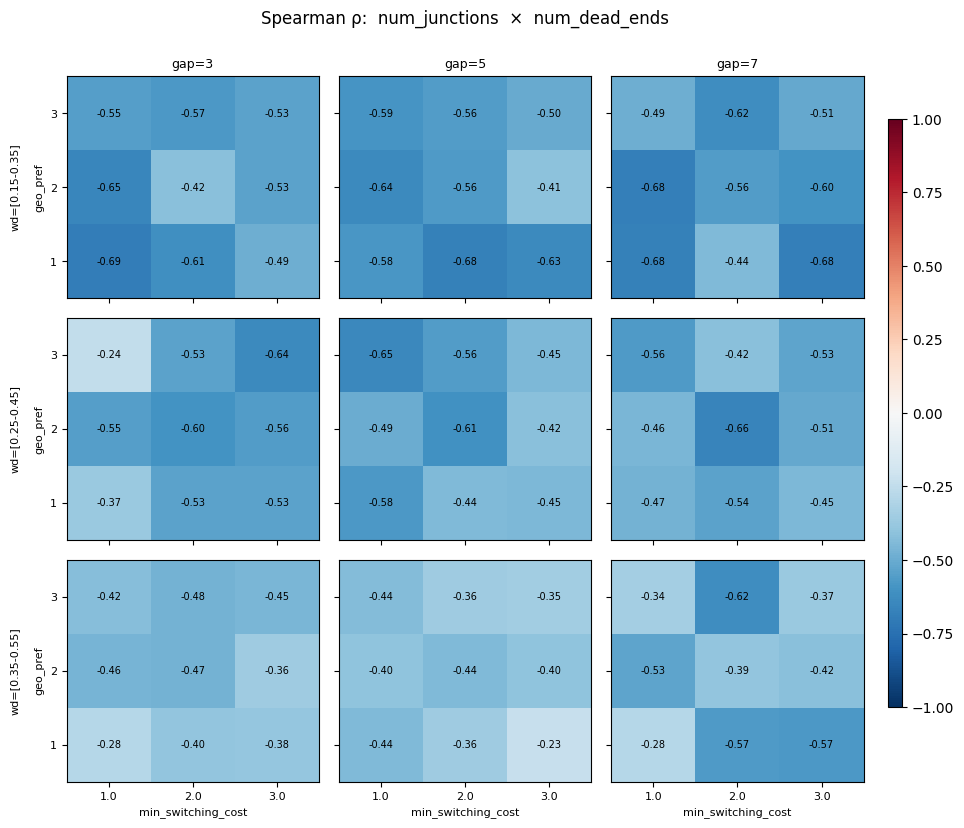

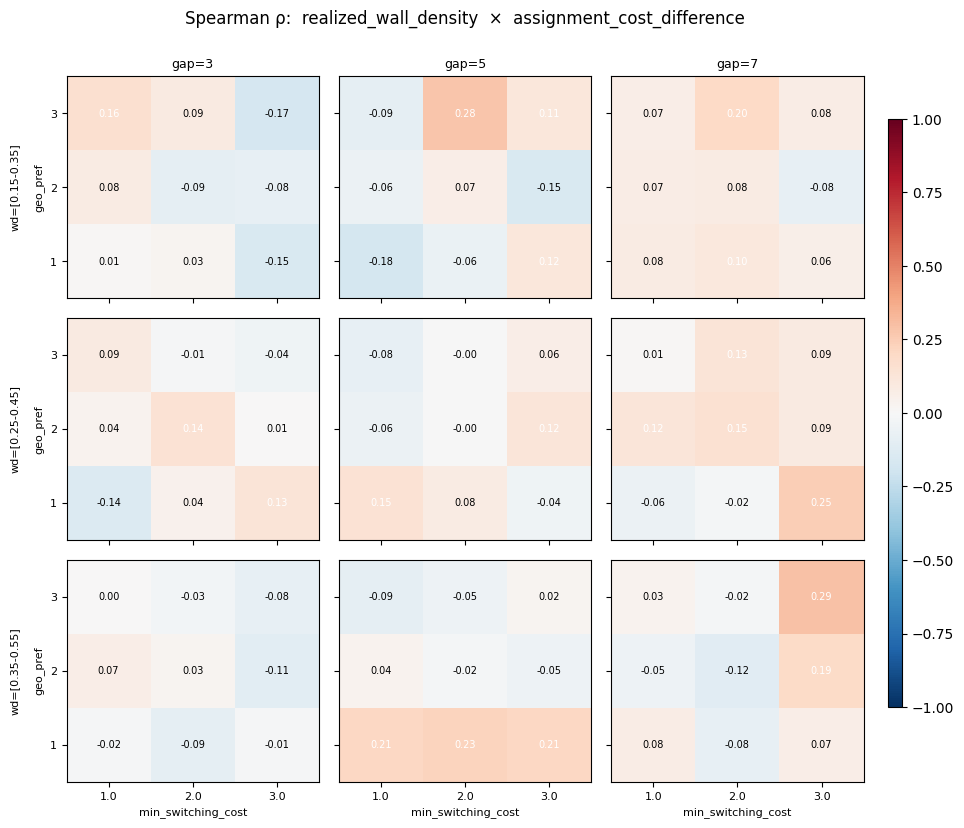

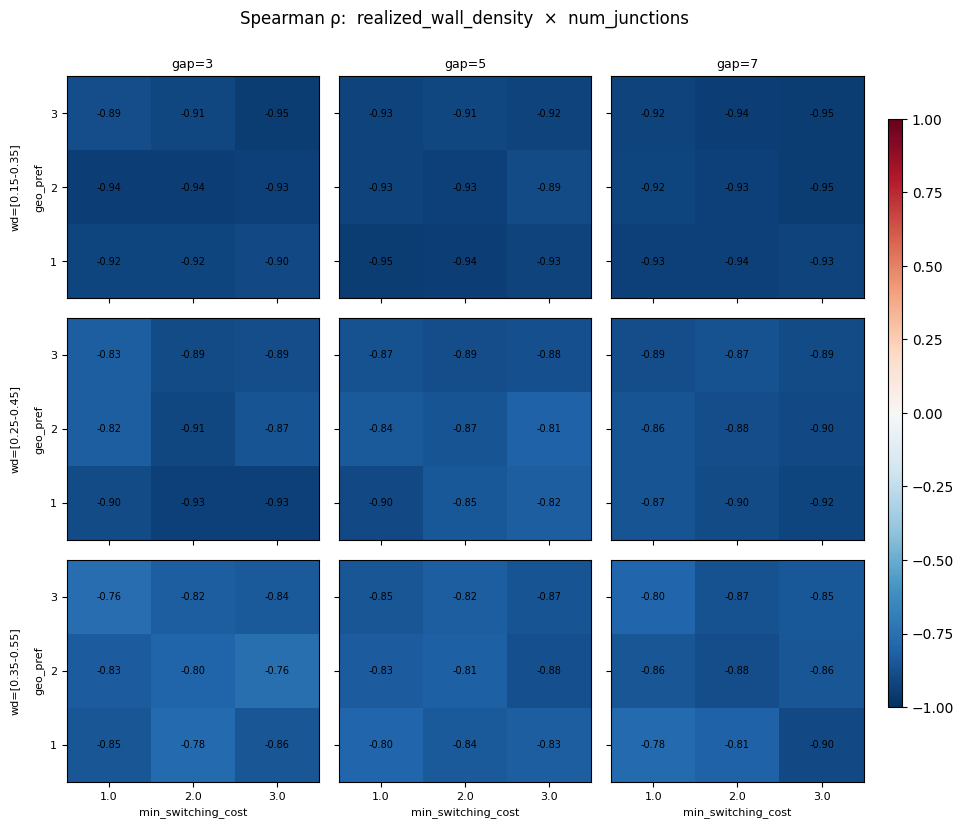

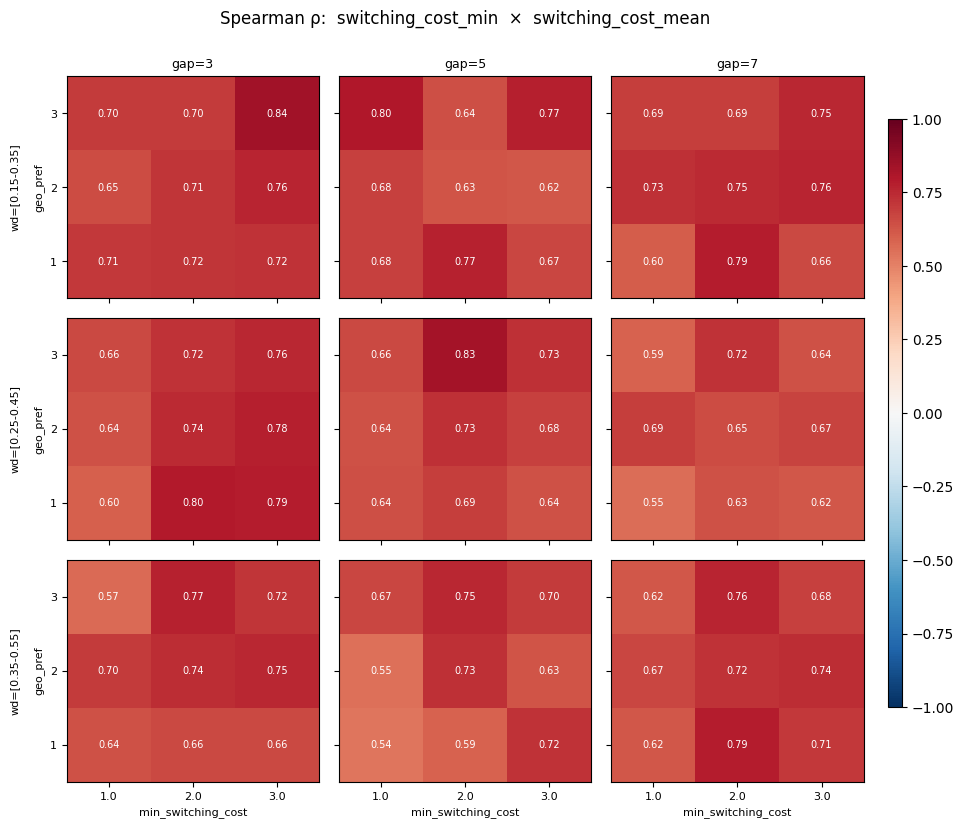

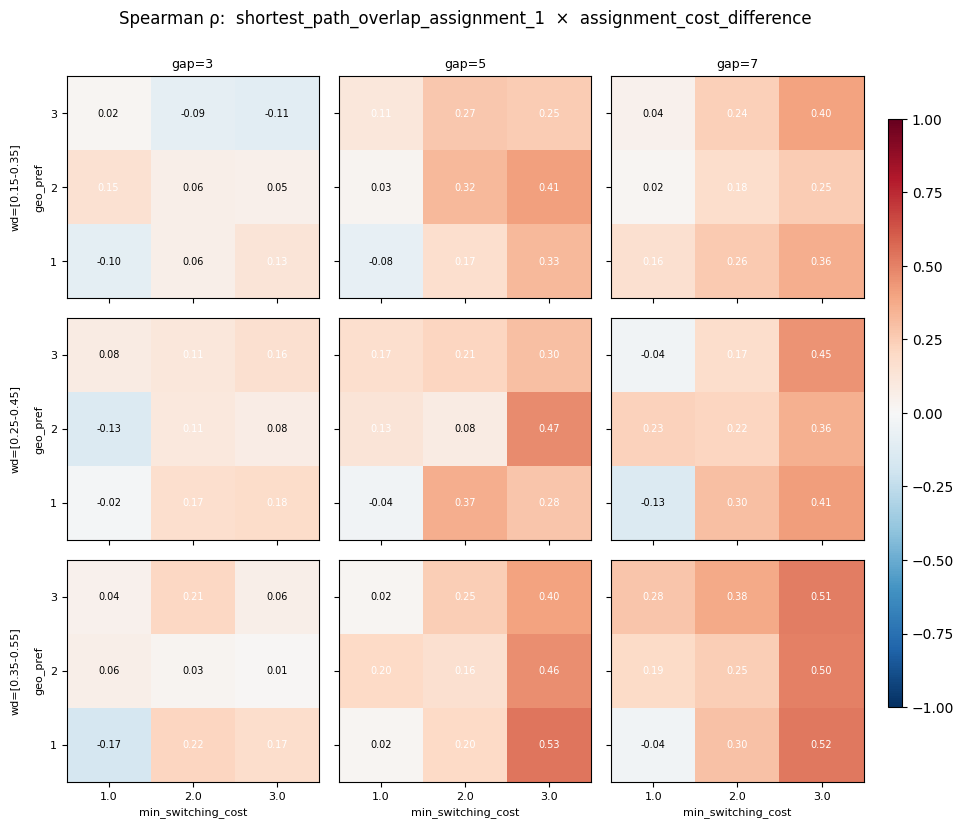

In [5]:
for key in pair_keys:
    x, y = key[len("corr__"):].split("__", 1)
    plot_metric_grid(df, key, f"Spearman ρ:  {x}  ×  {y}",
                     cmap="RdBu_r", vlim=(-1.0, 1.0))
    plt.show()

## 3. Non-communicating baseline results across the sweep

Two figures per baseline: **mean success** (fraction of trials on which the baseline coordinates successfully, averaged across 100 layouts) and **mean cost** (average steps-to-success on successful trials, averaged across layouts).

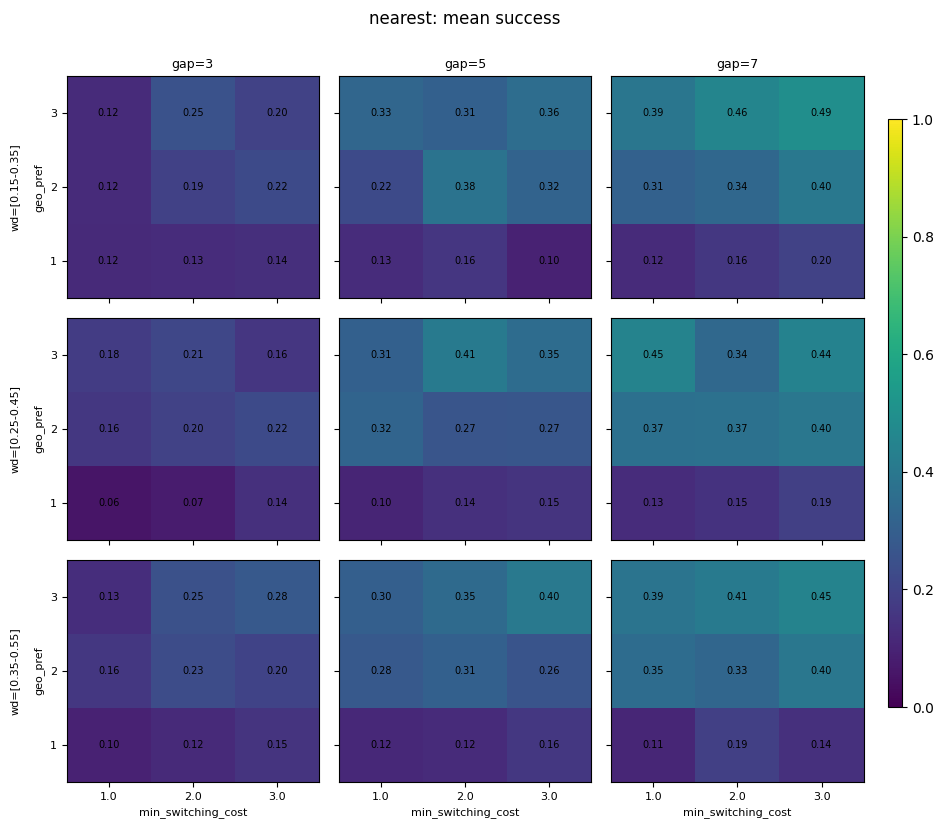

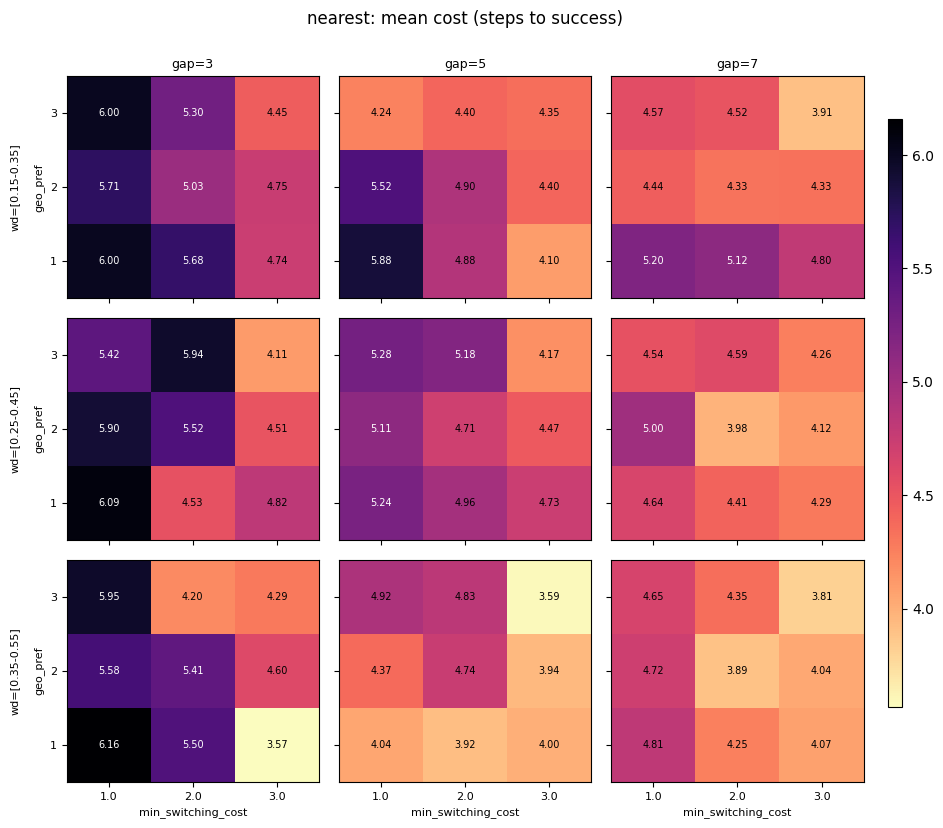

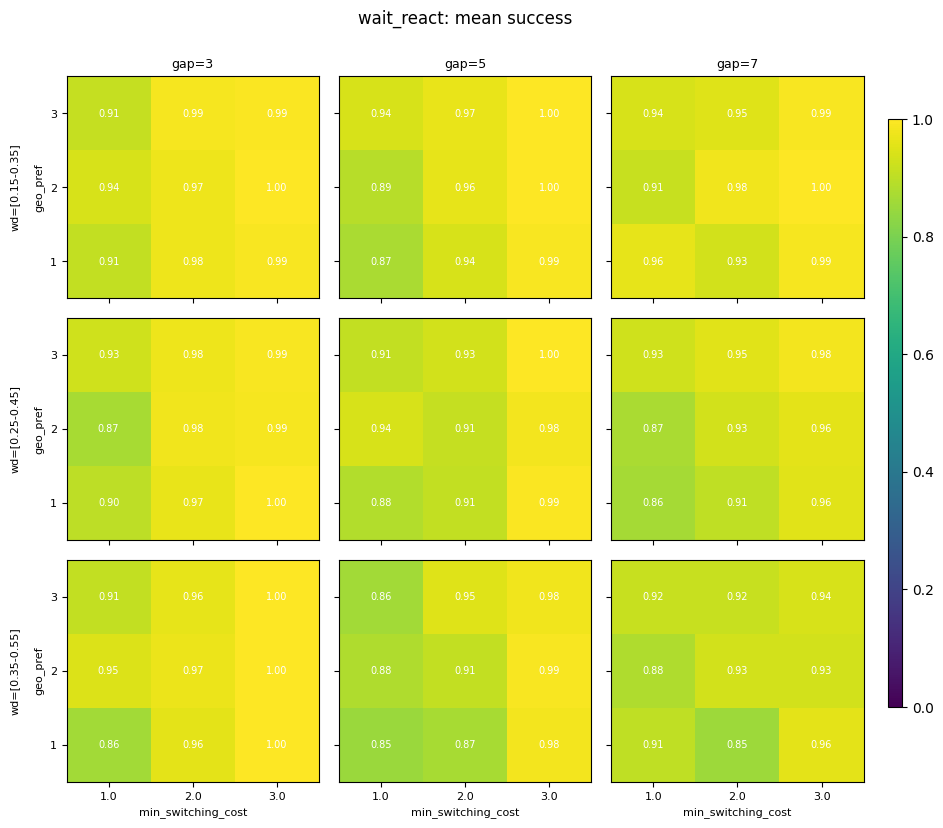

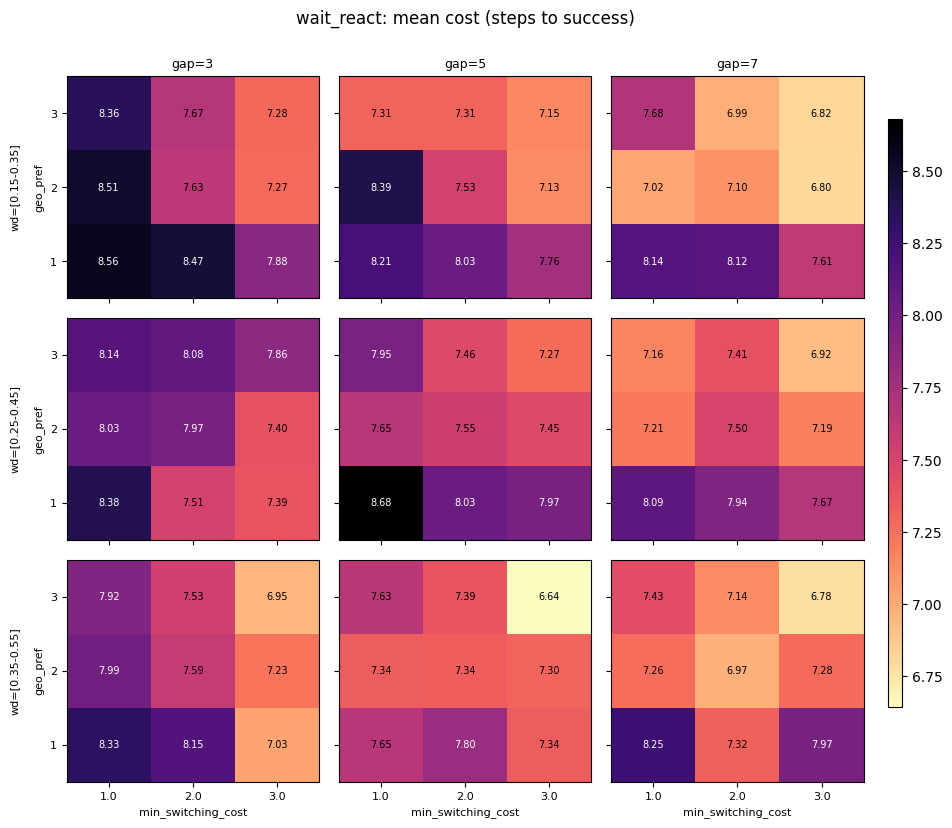

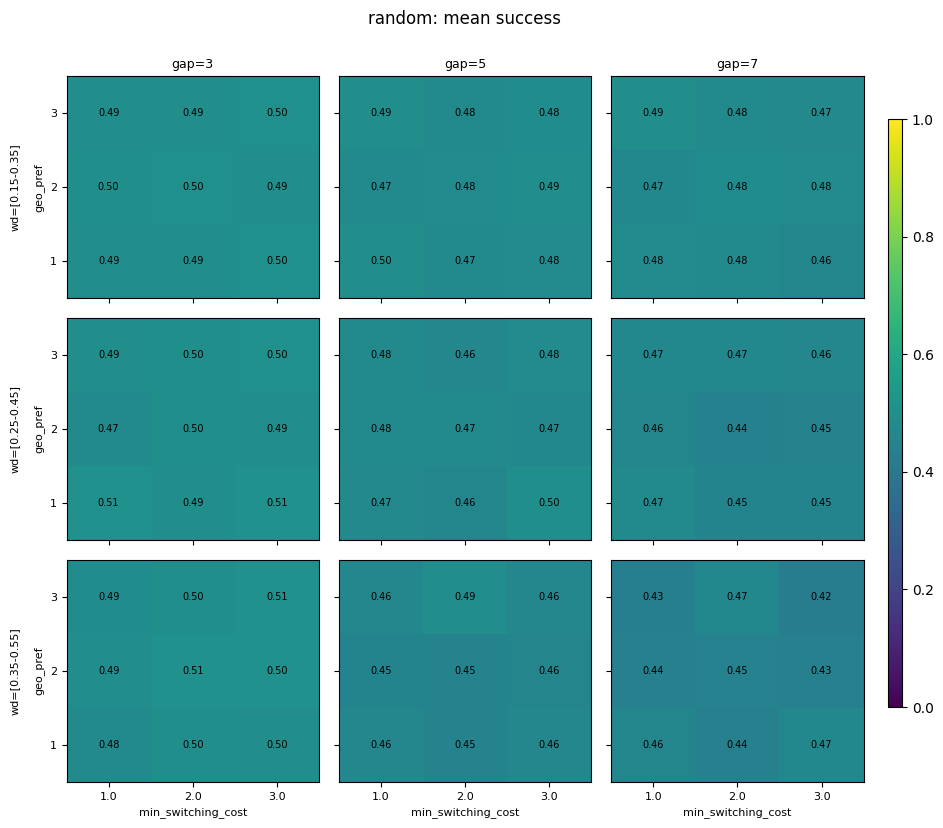

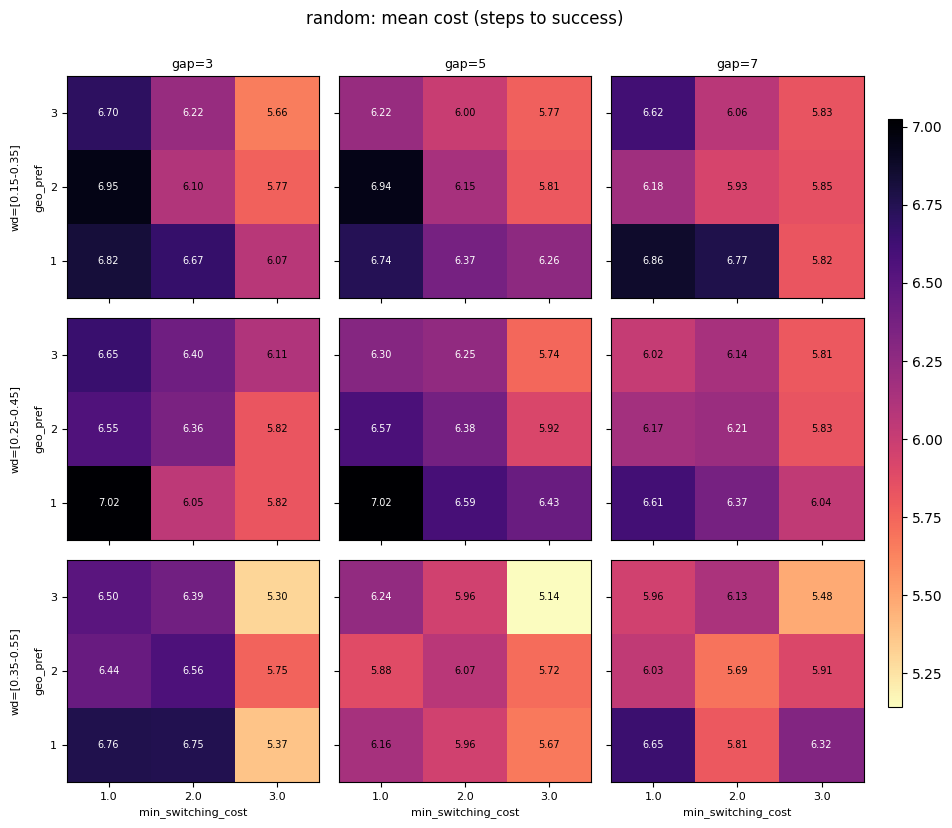

In [6]:
for name in BASELINE_NAMES:
    plot_metric_grid(df, f"base__{name}__mean_success",
                     f"{name}: mean success", cmap="viridis", vlim=(0.0, 1.0))
    plt.show()
    plot_metric_grid(df, f"base__{name}__mean_cost",
                     f"{name}: mean cost (steps to success)", cmap="magma_r")
    plt.show()